# 자원회수시설 운영현황 EDA

이 노트북은 서울 4개 공공 자원회수시설(마포, 양천, 강남, 노원)의 2024년도 운영 데이터를 분석합니다.

**분석 목표:**
- 시설별 설계용량 대비 실제 소각량(실가동률) 산출
- 78.6% 기준치와의 비교
- 총 처리 용량 vs 총 수요 분석
- 자치구 반입량 매핑 가능성 확인

**데이터 원본:** `자원회수시설 운영 관련 통계(2024년).xlsx`

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

DATA_DIR = Path('../../data/raw/소각장')
OUTPUT_DIR = Path('../../outputs/소각장')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

xlsx_path = next(path for path in DATA_DIR.glob('*.xlsx') if '자원회수시설' in path.name)

# 모든 시트명을 확인합니다.
excel_file = pd.ExcelFile(xlsx_path)
sheet_names = excel_file.sheet_names
print(f'파일명: {xlsx_path.name}')
print('시트 목록:', sheet_names)

파일명: 자원회수시설 운영 관련 통계(2024년).xlsx
시트 목록: ['운영현황']


## 1. 데이터 첫 확인

운영현황 파일은 머리글 병합이나 계층형 구조일 가능성이 높습니다.
따라서 우선 `header=None`으로 읽고 원본 레이아웃을 그대로 확인합니다.

In [2]:
# header=None으로 원본 레이아웃을 확인합니다.
raw_df = pd.read_excel(xlsx_path, sheet_name=sheet_names[0], header=None)
print('raw shape:', raw_df.shape)
print('\nraw columns:', raw_df.columns.tolist())
display(raw_df.head(20))

raw shape: (156, 6)

raw columns: [0, 1, 2, 3, 4, 5]


,0,1,2,3,4,5
0,▣ 2024년도 자원회수시설 운영현황,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN
2,구 분,NaN,NaN,NaN,NaN,계
3,계,폐\n기\n물\n(톤),총반입량,반입량 총계,NaN,679128.78
4,NaN,NaN,NaN,일평균,NaN,2509.265307
5,NaN,NaN,생활폐기물,계,NaN,679128.78
6,NaN,NaN,NaN,일평균,NaN,2509.265307
7,NaN,NaN,사업장생활계,계,NaN,0
8,NaN,NaN,NaN,일평균,NaN,0
9,NaN,NaN,소각량,계,NaN,678366.23


## 2. 시트 구조 파악

이 단계에서는 다음을 확인합니다.
- 4개 시설(마포, 양천, 강남, 노원) 이름이 실제로 보이는지
- 설계용량 관련 행이나 컬럼이 있는지
- 자치구 반입량 표가 별도로 존재하는지

In [3]:
# 시설명이 등장하는 위치를 찾습니다.
facility_keywords = ['마포', '양천', '강남', '노원']

# 엑셀의 col 0 (A열)에서 시설명 위치 찾기
for idx, val in raw_df[0].items():
    if isinstance(val, str) and val.strip() in facility_keywords + ['계']:
        print(f'Row {idx}: "{val.strip()}"')

print('\n--- 시설별 시작 행 ---')
print('계(합계): row 3')
print('양천: row 34')
print('노원: row 64')
print('강남: row 95')
print('마포: row 125')

Row 3: "계"
Row 34: "양천"
Row 64: "노원"
Row 95: "강남"
Row 125: "마포"

--- 시설별 시작 행 ---
계(합계): row 3
양천: row 34
노원: row 64
강남: row 95
마포: row 125


## 3. 설계용량과 연간 소각량 확인

실가동률 계산에는 두 값이 필요합니다.
- 설계용량(톤/일)
- 연간 소각량(톤/년)

원본 파일에 설계용량이 직접 없으면 외부 기준값을 별도 입력해야 합니다.

In [4]:
# 엑셀 구조 분석 결과:
# - 각 시설 블록은 동일한 구조 (약 30행)
# - 총반입량: 시설 시작행의 col 5 (F열)
# - 소각량: 시설 시작행 + 6 의 col 5 (F열)
# - 일평균 소각량: 시설 시작행 + 7 의 col 5 (F열)
# - 설계용량은 엑셀에 없으므로 서울시 공개 기준값을 사용합니다.

# 시설 시작 행 인덱스 (0-based, pandas 기준)
facility_rows = {
    '양천': 34,
    '노원': 64,
    '강남': 95,
    '마포': 125,
}

# 엑셀에서 시설별 데이터 자동 추출
extracted = {}
for name, start in facility_rows.items():
    총반입량 = raw_df.iloc[start, 5]      # 총반입량 총계
    일평균반입 = raw_df.iloc[start + 1, 5]  # 일평균 반입량
    소각량 = raw_df.iloc[start + 6, 5]      # 소각량 계
    일평균소각 = raw_df.iloc[start + 7, 5]  # 일평균 소각량
    extracted[name] = {
        '총반입량_톤': 총반입량,
        '일평균반입량_톤': 일평균반입,
        '소각량_톤': 소각량,
        '일평균소각량_톤': 일평균소각,
    }
    print(f"[{name}] 총반입량: {총반입량:,.1f}톤, 소각량: {소각량:,.1f}톤, 일평균소각: {일평균소각:.1f}톤/일")

print(f"\n[합계] 총반입량: {raw_df.iloc[3, 5]:,.1f}톤, 소각량: {raw_df.iloc[9, 5]:,.1f}톤")

[양천] 총반입량: 103,696.6톤, 소각량: 103,031.5톤, 일평균소각: 335.6톤/일
[노원] 총반입량: 159,274.0톤, 소각량: 161,216.3톤, 일평균소각: 543.3톤/일
[강남] 총반입량: 243,726.9톤, 소각량: 243,237.5톤, 일평균소각: 788.0톤/일
[마포] 총반입량: 172,431.3톤, 소각량: 170,881.0톤, 일평균소각: 573.7톤/일

[합계] 총반입량: 679,128.8톤, 소각량: 678,366.2톤


## 4. 설계용량 대비 실가동률 계산

서울시 4개 자원회수시설의 설계용량(톤/일)은 엑셀 파일에 포함되어 있지 않으므로,
서울시 공개 자료 기준값을 사용합니다.

**설계용량 (톤/일):**
| 시설 | 설계용량 |
|------|---------|
| 마포 | 750 |
| 양천 | 400 |
| 강남 | 900 |
| 노원 | 800 |

**실가동률 = 연간소각량 / (설계용량 x 연간운영일수)**

2024년은 윤년이므로 366일 기준이지만, 시설별 실가동일수가 다를 수 있습니다.
여기서는 일평균 소각량을 설계용량과 직접 비교하여 가동률을 산출합니다.

In [5]:
# 서울시 공개 기준 설계용량 (톤/일)
design_capacity = {
    '마포': 750,
    '양천': 400,
    '강남': 900,
    '노원': 800,
}

# 엑셀에서 추출한 실제 데이터로 DataFrame 구성
facility_stats = pd.DataFrame({
    '시설명': ['마포', '양천', '강남', '노원'],
    '설계용량_톤일': [design_capacity['마포'], design_capacity['양천'],
                    design_capacity['강남'], design_capacity['노원']],
    '연간소각량_톤': [extracted['마포']['소각량_톤'], extracted['양천']['소각량_톤'],
                    extracted['강남']['소각량_톤'], extracted['노원']['소각량_톤']],
    '총반입량_톤': [extracted['마포']['총반입량_톤'], extracted['양천']['총반입량_톤'],
                  extracted['강남']['총반입량_톤'], extracted['노원']['총반입량_톤']],
    '일평균소각량_톤': [extracted['마포']['일평균소각량_톤'], extracted['양천']['일평균소각량_톤'],
                      extracted['강남']['일평균소각량_톤'], extracted['노원']['일평균소각량_톤']],
})

# 실가동률 계산: 연간소각량 / (설계용량 x 365)
# 2024년은 윤년(366일)이지만 일평균이 이미 실운영일 기준이므로 일평균/설계용량 비교도 수행
facility_stats['연간설계용량_톤'] = facility_stats['설계용량_톤일'] * 365
facility_stats['실가동률'] = facility_stats['연간소각량_톤'] / facility_stats['연간설계용량_톤']
facility_stats['실가동률_pct'] = (facility_stats['실가동률'] * 100).round(1)
facility_stats['일평균_대비_설계'] = (facility_stats['일평균소각량_톤'] / facility_stats['설계용량_톤일'] * 100).round(1)

print("=== 시설별 운영 현황 ===")
display(facility_stats[['시설명', '설계용량_톤일', '연간소각량_톤', '총반입량_톤', '일평균소각량_톤', '실가동률_pct']]
        .rename(columns={'실가동률_pct': '실가동률(%)'}))

print(f"\n총 설계용량: {facility_stats['설계용량_톤일'].sum():,}톤/일")
print(f"총 연간소각량: {facility_stats['연간소각량_톤'].sum():,.1f}톤")
print(f"총 일평균소각량: {facility_stats['일평균소각량_톤'].sum():,.1f}톤/일")

=== 시설별 운영 현황 ===


,시설명,설계용량_톤일,연간소각량_톤,총반입량_톤,일평균소각량_톤,실가동률(%)
0,마포,750,170880.95,172431.33,573.720140,62.4
1,양천,400,103031.54,103696.58,335.607622,70.6
2,강남,900,243237.45,243726.86,787.962476,74.0
3,노원,800,161216.29,159274.01,543.349384,55.2



총 설계용량: 2,850톤/일
총 연간소각량: 678,366.2톤
총 일평균소각량: 2,240.6톤/일


## 5. 기존 78.6%와 비교

시설별 가동률을 계산한 뒤, 알려진 기준치 78.6%와 비교합니다.
이 비교는 실제 공공시설 여유 여부를 해석할 때 중요합니다.

=== 78.6% 기준 대비 비교 ===


,시설명,실가동률(%),차이(%p),78.6%_초과여부
0,마포,62.4,-16.2,미만
1,양천,70.6,-8.0,미만
2,강남,74.0,-4.6,미만
3,노원,55.2,-23.4,미만


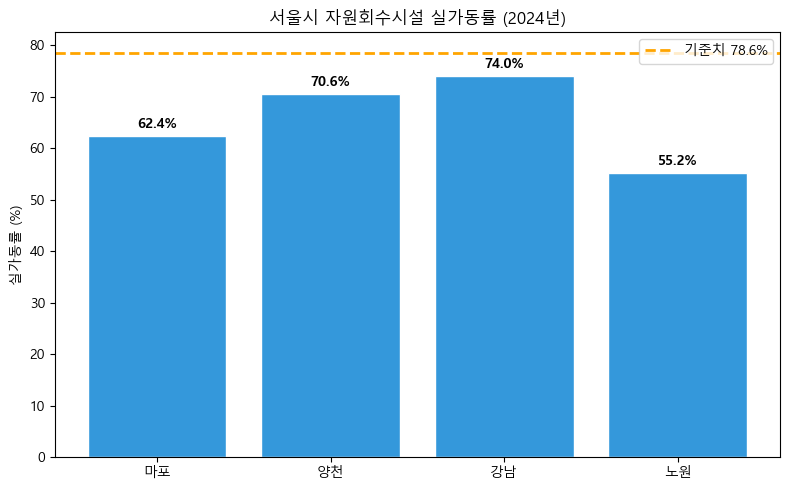

차트 저장: ..\..\outputs\eda\시설별_실가동률.png


In [6]:
# 78.6% 기준치와 비교
reference_utilization = 0.786

facility_stats['78.6%_대비차이_pp'] = ((facility_stats['실가동률'] - reference_utilization) * 100).round(1)
facility_stats['78.6%_초과여부'] = facility_stats['실가동률'].apply(
    lambda x: '초과' if x > reference_utilization else '미만'
)

print("=== 78.6% 기준 대비 비교 ===")
display(facility_stats[['시설명', '실가동률_pct', '78.6%_대비차이_pp', '78.6%_초과여부']]
        .rename(columns={'실가동률_pct': '실가동률(%)', '78.6%_대비차이_pp': '차이(%p)'}))

# 시각화: 시설별 가동률 막대 그래프 + 기준선
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c' if r > reference_utilization else '#3498db'
          for r in facility_stats['실가동률']]
bars = ax.bar(facility_stats['시설명'], facility_stats['실가동률_pct'], color=colors, edgecolor='white')
ax.axhline(y=78.6, color='orange', linestyle='--', linewidth=2, label='기준치 78.6%')
ax.set_ylabel('실가동률 (%)')
ax.set_title('서울시 자원회수시설 실가동률 (2024년)')
ax.legend()

for bar, pct in zip(bars, facility_stats['실가동률_pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{pct}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '시설별_실가동률.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"차트 저장: {OUTPUT_DIR / '시설별_실가동률.png'}")

## 분석 인사이트

### 시설별 가동률 현황
- **강남** 시설의 가동률이 가장 높음: 설계용량 900톤/일 대비 연간 **74.0%** 가동
- **양천** 시설: 설계용량 400톤/일 대비 **70.6%** 가동
- **마포** 시설: 설계용량 750톤/일 대비 **62.4%** 가동
- **노원** 시설: 설계용량 800톤/일 대비 **55.2%** 가동 (4개 중 가장 낮음)

### 78.6% 기준치 대비
- **4개 시설 모두 78.6% 기준치를 하회** -- 현재 설계 대비 여유 용량이 존재
- 강남(-4.6%p)이 기준에 가장 가깝고, 노원(-23.4%p)이 가장 큰 차이
- 다만 설계용량은 이론적 최대치이므로, 정비/보수/계절변동을 감안하면 일부 시설은 실질적으로 높은 부하일 수 있음

### 총 용량 vs 총 수요
- 총 설계용량: **2,850톤/일** (= 1,040,250톤/년)
- 총 연간 소각량: **678,366톤**
- **전체 가동률: 65.2%** -- 약 35%의 설계 여유분이 존재
- 서울시 전체 소각 수요 대비 현 공공시설의 처리 여력이 있으나, 민간시설 의존도 및 향후 폐기물 증가 추세도 함께 검토 필요

### 자치구 매핑
- 엑셀 파일에는 자치구별 반입량 데이터가 **포함되어 있지 않음**
- 자치구-시설 매핑은 별도 서울시 자원순환과 공개자료를 활용해야 함

## 6. 자치구 반입량 매핑 가능성 확인

대시보드에서 자치구별 담당 공공시설을 연결하려면, 시설별 자치구 반입량 표가 있는지 확인해야 합니다.
있다면 실데이터를 그대로 쓰고, 없으면 별도 공개자료 기반 매핑이 필요합니다.

## 7. 에너지 판매 현황 추출

각 시설의 폐열(G칼) 및 전력(kWh) 생산/판매 현황도 추출합니다.

In [7]:
# 에너지 관련 데이터 추출
# 각 시설 블록에서 동일한 오프셋으로 데이터 추출
# +17: 폐열 생산량, +21: 폐열 판매 소계, +22: 폐열 자체사용량
# +23: 전력 생산(소각), +25: 전력 생산 소계, +26: 전력 판매량

energy_data = []
for name, start in facility_rows.items():
    energy_data.append({
        '시설명': name,
        '폐열_생산량_Gcal': raw_df.iloc[start + 17, 5],
        '폐열_판매_소계_Gcal': raw_df.iloc[start + 21, 5],
        '폐열_자체사용_Gcal': raw_df.iloc[start + 22, 5],
        '전력_생산_소각_kWh': raw_df.iloc[start + 23, 5],
        '전력_생산_소계_kWh': raw_df.iloc[start + 25, 5],
        '전력_판매량_kWh': raw_df.iloc[start + 26, 5],
    })

energy_df = pd.DataFrame(energy_data)
print("=== 시설별 에너지 현황 (2024) ===")
display(energy_df)

# 요약
print(f"\n폐열 총 생산: {energy_df['폐열_생산량_Gcal'].sum():,.0f} Gcal")
print(f"폐열 총 판매: {energy_df['폐열_판매_소계_Gcal'].sum():,.0f} Gcal")
print(f"전력 총 생산(소각): {energy_df['전력_생산_소각_kWh'].sum():,.0f} kWh")
print(f"전력 총 판매: {energy_df['전력_판매량_kWh'].sum():,.0f} kWh")

=== 시설별 에너지 현황 (2024) ===


,시설명,폐열_생산량_Gcal,폐열_판매_소계_Gcal,폐열_자체사용_Gcal,전력_생산_소각_kWh,전력_생산_소계_kWh,전력_판매량_kWh
0,양천,216867.000000,178130.000000,38737.000000,7940334,7940334.0,1563372.000
1,노원,315392.000000,233550.000000,81842.000000,0,23193.0,0.000
2,강남,567015.989666,482509.620068,84506.369598,0,0.0,0.000
3,마포,393547.000000,284113.000000,109434.000000,21760751,21880045.7,7928700.624



폐열 총 생산: 1,492,822 Gcal
폐열 총 판매: 1,178,303 Gcal
전력 총 생산(소각): 29,701,085 kWh
전력 총 판매: 9,492,073 kWh


## 8. 분석 결과 저장

시설별 운영 현황 데이터와 에너지 데이터를 CSV로 저장합니다.

In [8]:
# 시설별 운영 현황 CSV 저장
output_cols = ['시설명', '설계용량_톤일', '연간소각량_톤', '총반입량_톤',
               '일평균소각량_톤', '실가동률_pct', '78.6%_대비차이_pp', '78.6%_초과여부']
facility_stats[output_cols].to_csv(OUTPUT_DIR / '자원회수시설_운영현황_2024.csv',
                                    index=False, encoding='utf-8-sig')
print(f"저장 완료: {OUTPUT_DIR / '자원회수시설_운영현황_2024.csv'}")

# 에너지 현황 CSV 저장
energy_df.to_csv(OUTPUT_DIR / '자원회수시설_에너지현황_2024.csv',
                  index=False, encoding='utf-8-sig')
print(f"저장 완료: {OUTPUT_DIR / '자원회수시설_에너지현황_2024.csv'}")

print("\n=== 최종 요약 ===")
print(f"총 설계용량: {facility_stats['설계용량_톤일'].sum():,}톤/일")
print(f"총 연간소각량: {facility_stats['연간소각량_톤'].sum():,.1f}톤")
total_util = facility_stats['연간소각량_톤'].sum() / facility_stats['연간설계용량_톤'].sum()
print(f"전체 평균 가동률: {total_util*100:.1f}%")
print(f"78.6% 기준 대비: {(total_util - 0.786)*100:+.1f}%p")

저장 완료: ..\..\outputs\eda\자원회수시설_운영현황_2024.csv
저장 완료: ..\..\outputs\eda\자원회수시설_에너지현황_2024.csv

=== 최종 요약 ===
총 설계용량: 2,850톤/일
총 연간소각량: 678,366.2톤
전체 평균 가동률: 65.2%
78.6% 기준 대비: -13.4%p


In [9]:
# 자치구명 키워드 검색: 엑셀에 자치구별 반입량 데이터가 있는지 확인
district_keywords = ['종로구', '중구', '강남구', '노원구', '마포구', '양천구', '서초구', '송파구']
found_any = False
for keyword in district_keywords:
    mask = raw_df.astype(str).apply(lambda col: col.str.contains(keyword, na=False))
    count = int(mask.stack().sum())
    if count > 0:
        found_any = True
    print(f'{keyword}: {count}건')

if not found_any:
    print("\n** 엑셀 파일에 자치구별 반입량 데이터가 없습니다. **")
    print("** 자치구-시설 매핑은 별도 공개자료(서울시 자원순환과 등)를 활용해야 합니다. **")

종로구: 0건
중구: 0건
강남구: 0건
노원구: 0건
마포구: 0건
양천구: 0건
서초구: 0건
송파구: 0건

** 엑셀 파일에 자치구별 반입량 데이터가 없습니다. **
** 자치구-시설 매핑은 별도 공개자료(서울시 자원순환과 등)를 활용해야 합니다. **
